<a href="https://colab.research.google.com/github/lawho13/ML_Pricing/blob/main/linear_model_backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import ElasticNet, SGDRegressor
from collections import defaultdict
from sklearn.decomposition import PCA
from kneed import KneeLocator
import matplotlib.dates as mdates
from scipy.optimize import minimize

path = "/common/home/lh811/Documents/cleaned.csv"

In [2]:
# Assuming df is now cleaned and good to go
def load(path):
  # load csv into a pd dataframe; cast values to np.float32's for memory purposes; turn values in date to proper datetime objects; sort rows by permno, and inside permno groups, date
  df = pd.read_csv(path, dtype={col: np.float32 for col in pd.read_csv(path, nrows=0).columns if col not in ['DATE', 'year_month', 'permno']})
  df['DATE'] = pd.to_datetime(df['DATE'])
  df['year_month'] = pd.to_datetime(df['year_month']).dt.to_period('M')
  df = df.sort_values(['permno', 'DATE']).reset_index(drop=True)

  print(f"Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
  print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns")

  return df


In [3]:
clean = load(path)

Memory: 1.25 GB
Loaded 3016262 rows and 101 columns


In [4]:
def get_features_and_target(df, target_col='monthly_excess_ret'):
  drop_cols = ['DATE', 'year_month', 'permno', 'monthly_ret_raw', 'RF', target_col]
  feature_cols = [c for c in df.columns if c not in drop_cols]
  temp_df = df.dropna(subset=feature_cols + [target_col])

  X = temp_df[feature_cols].values
  y = temp_df[target_col].values

  return X, y, temp_df


def split_paper(df, initial_train_years=18, 
                val_years=12, test_years=1, date_col="DATE"):
    
    df = df.sort_values(date_col).reset_index(drop=True)

    start_date = df[date_col].min()
    end_date   = df[date_col].max()

    train_end = start_date + pd.DateOffset(years=initial_train_years)

    while True:

        val_start = train_end
        val_end   = val_start + pd.DateOffset(years=val_years)

        test_start = val_end
        test_end   = test_start + pd.DateOffset(years=test_years)

        if test_end > end_date:
            break

        train_df = df[df[date_col] < train_end]

        val_df = df[
            (df[date_col] >= val_start) &
            (df[date_col] <  val_end)
        ]

        test_df = df[
            (df[date_col] >= test_start) &
            (df[date_col] <  test_end)
        ]

        print(
            f"Train: {train_df[date_col].min().date()} → "
            f"{train_df[date_col].max().date()} | "
            f"Val: {val_df[date_col].min().date()} → "
            f"{val_df[date_col].max().date()} | "
            f"Test: {test_df[date_col].min().date()} → "
            f"{test_df[date_col].max().date()}"
        )

        yield train_df, val_df, test_df

        # move forward ONE year only
        train_end = train_end + pd.DateOffset(years=1)

def r2(y_test, y_pred):
    num = np.sum((y_test - y_pred)**2)
    den = np.sum(y_test**2)
    r2 = 100*(1 - (num/den))
    return r2

The Workflow for your Forecast:
Step 1: Run your tuning loop on the very last available window (e.g., Train 1985–2024, Val 2025).
Step 2: Find the "Optimal" params for that specific moment (e.g., $\alpha=0.01, l1=0.1$).
Step 3: Use those specific params to train on all data up to today.
Step 4: Predict next month.

In [5]:
def huber_loss_ols(theta, X, y, xi):
  """
  theta : coefficient vector INCLUDING intercept
  X     : feature matrix WITH intercept column
  y     : target vector
  xi    : huber threshold
  """

  residuals = y - X @ theta
  abs_resid = np.abs(residuals)

  loss = np.where(
      abs_resid <= xi,
      residuals**2,
      2 * xi * abs_resid - xi**2
  )

  return np.mean(loss)

def huber_ols(X, y, delta):
  '''
  X: already has intercept
  delta: threshold for Huber loss
  y: response
  '''
  beta0 = np.zeros(X.shape[1])
  result = minimize(huber_loss_ols, beta0, args=(X, y, delta))
  return result.x

def huber_pred(X, beta):
  return X @ beta


In [6]:
ols_oos_results = []
olsh_oos_results = []
ols_predictions = []

for train, val, test in split_paper(clean):
  X_train, y_train, _ = get_features_and_target(train)
  X_val, y_val, _  = get_features_and_target(val)
  X_test, y_test, test_df  = get_features_and_target(test)

  X_train_constant = sm.add_constant(X_train)
  X_val_constant  = sm.add_constant(X_val)
  X_test_constant = sm.add_constant(X_test)

  model = sm.OLS(y_train, X_train_constant).fit()
  train_pred = model.predict(X_train_constant) # train pred
  val_pred = model.predict(X_val_constant) # val pred
  r2_val_ols = r2(y_val, val_pred)
  mse_val_ols = mean_squared_error(y_val, val_pred)

  # OLS prediction
  y_pred = model.predict(X_test_constant)
  r2_test_ols = r2(y_test, y_pred)
  mse_test_ols = mean_squared_error(y_test, y_pred)

  # Huber Loss OLS
  resid = y_train - train_pred # param
  delta = np.quantile(np.abs(resid), 0.999) # param

  model_huber = huber_ols(X_train_constant, y_train, delta) # Huber
  y_val_pred_huber = huber_pred(X_val_constant, model_huber) # Huber

  r2_huber_val = r2(y_val, y_val_pred_huber)
  mse_huber_val = mean_squared_error(y_val, y_val_pred_huber)
  y_pred_huber = huber_pred(X_test_constant, model_huber)
  r2_huber = r2(y_test, y_pred_huber)
  mse_huber = mean_squared_error(y_test, y_pred_huber)

  ols_predictions.append(
    pd.DataFrame({
    'permno': test_df['permno'].values,
    'DATE': test_df['DATE'].values,
    'true': y_test,
    'ols':y_pred,
    'olsh':y_pred_huber
  }))
  


  olsh_oos_results.append({
      'val_start': val['DATE'].min().date(),
      'val_end': val['DATE'].max().date(),

      'test_start': test['DATE'].min().date(),
      'test_end': test['DATE'].max().date(),

      'r2_val': r2_huber_val,
      'mse_val': mse_huber_val,

      'mse_test': mse_huber,
      'r2_test': r2_huber
  })

  ols_oos_results.append({
      'val_start': val['DATE'].min().date(),
      'val_end': val['DATE'].max().date(),

      'test_start': test['DATE'].min().date(),
      'test_end': test['DATE'].max().date(),

      'r2_val': r2_val_ols,
      'mse_val': mse_val_ols,

      'mse_test': mse_test_ols,
      'r2_test': r2_test_ols
  })

# print(f"Window {test['DATE'].max().year} | OOS R^2: {r2_test}")

# Just visually checking the linear OLS model

ols_predictions_df = pd.concat(ols_predictions, ignore_index=True)
ols_predictions_df.to_csv('/common/home/lh811/Documents/ML_Pricing/data/aggregate_model_performance/ols_predictions.csv', index=False)


Train: 1985-01-31 → 2002-12-31 | Val: 2003-01-31 → 2015-01-30 | Test: 2015-02-27 → 2016-01-29
Train: 1985-01-31 → 2004-01-30 | Val: 2004-02-27 → 2016-01-29 | Test: 2016-02-29 → 2016-12-30
Train: 1985-01-31 → 2004-12-31 | Val: 2005-01-31 → 2016-12-30 | Test: 2017-01-31 → 2017-12-29
Train: 1985-01-31 → 2005-12-30 | Val: 2006-01-31 → 2017-12-29 | Test: 2018-01-31 → 2018-12-31
Train: 1985-01-31 → 2006-12-29 | Val: 2007-01-31 → 2018-12-31 | Test: 2019-01-31 → 2019-12-31
Train: 1985-01-31 → 2007-12-31 | Val: 2008-01-31 → 2019-12-31 | Test: 2020-01-31 → 2021-01-29


In [7]:
# Huber Loss extension
# Robust to Outliers

def huber_loss(y_true, y_pred, delta):
  error = y_true - y_pred
  loss = np.where(
      np.abs(error) <= delta,
      error**2,
      2*np.abs(error)*delta - delta**2
  )
  return np.mean(loss)

In [ ]:
en_predictions = []
en_oos_results = []
enh_oos_results = []

# Hyperparameter grids
lambda_grid = np.logspace(-4, -1, 15)
rho = 0.5

for train, val, test in split_paper(clean):
    X_train, y_train, _ = get_features_and_target(train)
    X_val, y_val, _     = get_features_and_target(val)
    X_test, y_test, test_df   = get_features_and_target(test)

    # Track parameters instead of mutable model objects
    best_val_mse = np.inf
    best_en_alpha = None
    best_en_l1 = None

    best_val_huber = np.inf
    best_enh_alpha = None
    best_enh_l1 = None

    # -----------------------------------------------------------------
    # PHASE 1: HYPERPARAMETER TUNING
    # -----------------------------------------------------------------
    for alpha in lambda_grid:
        
        # scale alpha for size of data
        sgd_alpha = alpha / X_train.shape[0]

        # 1. Fit Standard Elastic Net via SGD (optimized for MSE)
        model_en = SGDRegressor(
            loss='squared_error',
            penalty='elasticnet',
            alpha=sgd_alpha,
            l1_ratio=rho,
            fit_intercept=True,
            max_iter=10000,
            random_state=13
        )
        model_en.fit(X_train, y_train)
        y_val_pred_en = model_en.predict(X_val)

        # Standard EN MSE Selection 
        val_mse = mean_squared_error(y_val, y_val_pred_en)
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_en_alpha = alpha
            best_en_l1 = rho

        # 2. Fit Huber Elastic Net (Optimizes Robust Loss)
        y_train_pred_en = model_en.predict(X_train)
        resid = y_train - y_train_pred_en
        delta = np.quantile(np.abs(resid), 0.999) 

        model_enh = SGDRegressor(
            loss='huber',
            epsilon=delta,          # Maps to tuning parameter \xi in Equation (6)
            penalty='elasticnet',
            alpha=sgd_alpha,
            l1_ratio=rho,
            fit_intercept=True,
            max_iter=10000,
            random_state=13
        )
        model_enh.fit(X_train, y_train)
        y_val_pred_enh = model_enh.predict(X_val)

        # --- EN Huber Selection ---
        # Scale by 0.5 (doesn't change the magnitude comparison but matches the SGD loss)
        val_huber = 0.5 * huber_loss(y_val, y_val_pred_enh, delta)
        if val_huber < best_val_huber:
            best_val_huber = val_huber
            best_enh_alpha = alpha
            best_enh_l1 = rho

    # =================================================================
    # refit the optimal models
    # =================================================================
    
    # 1. Final MSE Optimized Model
    final_en_alpha = best_en_alpha / X_train.shape[0]
    best_en_model = SGDRegressor(
        loss='squared_error',
        penalty='elasticnet',
        alpha=final_en_alpha,
        l1_ratio=best_en_l1,
        fit_intercept=True,
        max_iter=10000,
        random_state=13
    )
    best_en_model.fit(X_train, y_train)
    en_val_pred = best_en_model.predict(X_val)
    en_test_pred = best_en_model.predict(X_test)

    # 2. Final Huber Selected Model
    final_train_resid = y_train - best_en_model.predict(X_train)
    final_delta = np.quantile(np.abs(final_train_resid), 0.999)
    final_sgd_alpha = best_enh_alpha / X_train.shape[0]

    best_enh_model = SGDRegressor(
        loss='huber',
        epsilon=final_delta,
        penalty='elasticnet',
        alpha=final_sgd_alpha,
        l1_ratio=best_enh_l1,
        fit_intercept=True,
        max_iter=10000,
        random_state=13
    )
    best_enh_model.fit(X_train, y_train)
    enh_val_pred = best_enh_model.predict(X_val)
    enh_test_pred = best_enh_model.predict(X_test)

    # =================================================================
    # model evaluation
    # =================================================================
    en_oos_results.append({
        'test_start': test['DATE'].min().date(),
        'test_end': test['DATE'].max().date(),
        'best_alpha': best_en_alpha,
        'best_l1_ratio': best_en_l1,
        'mse_val': best_val_mse,
        'r2_val': r2(y_val, en_val_pred),
        'mse_test': mean_squared_error(y_test, en_test_pred),
        'r2_test': r2(y_test, en_test_pred)
    })

    enh_oos_results.append({
        'test_start': test['DATE'].min().date(),
        'test_end': test['DATE'].max().date(),
        'best_alpha': best_enh_alpha,
        'best_l1_ratio': best_enh_l1,
        'huber_val': best_val_huber,
        'r2_val': r2(y_val, enh_val_pred),
        'mse_test': mean_squared_error(y_test, enh_test_pred),
        'r2_test': r2(y_test, enh_test_pred)
    })

    en_predictions.append(
        pd.DataFrame({
            'permno': test_df['permno'].values,
            'DATE': test_df['DATE'].values,
            'true': y_test,
            'en': en_test_pred,
            'enh': enh_test_pred
        })
    )

en_predictions_df = pd.concat(en_predictions, ignore_index=True)
en_predictions_df.to_csv(
    '/common/home/lh811/Documents/ML_Pricing/data/aggregate_model_performance/en_predictions.csv',
    index=False)

Train: 1985-01-31 → 2002-12-31 | Val: 2003-01-31 → 2015-01-30 | Test: 2015-02-27 → 2016-01-29
Train: 1985-01-31 → 2004-01-30 | Val: 2004-02-27 → 2016-01-29 | Test: 2016-02-29 → 2016-12-30
Train: 1985-01-31 → 2004-12-31 | Val: 2005-01-31 → 2016-12-30 | Test: 2017-01-31 → 2017-12-29
Train: 1985-01-31 → 2005-12-30 | Val: 2006-01-31 → 2017-12-29 | Test: 2018-01-31 → 2018-12-31
Train: 1985-01-31 → 2006-12-29 | Val: 2007-01-31 → 2018-12-31 | Test: 2019-01-31 → 2019-12-31
Train: 1985-01-31 → 2007-12-31 | Val: 2008-01-31 → 2019-12-31 | Test: 2020-01-31 → 2021-01-29


In [11]:
en_oos_results_df = pd.DataFrame(en_oos_results)
enh_oos_results_df = pd.DataFrame(enh_oos_results)

In [12]:
en_oos_results_df[['best_alpha', 'best_l1_ratio']].value_counts()
enh_oos_results_df[['best_alpha', 'best_l1_ratio']].value_counts()

best_alpha  best_l1_ratio
0.1         0.5              6
Name: count, dtype: int64

In [13]:
# PCR (Principle Component Regression)

def optimal_components(X_train, y_train, X_val, y_val):
  pca = PCA()

  pca.fit(X_train)
  explained_variance = pca.explained_variance_ratio_
  cumulative_variance = np.cumsum(explained_variance)

  max_pcs = min(20, X_train.shape[1])
  pcs = np.arange(1, max_pcs + 1)

  cumulative_variance = cumulative_variance[:max_pcs]

  kneedle = KneeLocator(pcs, cumulative_variance, curve="concave", direction="increasing" )
  knee_val = kneedle.knee

  return knee_val

def pca_model():
  pcr_predictions = []
  pcr_oos_results = []
  for train, val, test in split_paper(clean):
    X_train, y_train, _ = get_features_and_target(train)
    X_val, y_val, _ = get_features_and_target(val)
    X_test, y_test, test_df = get_features_and_target(test)

    optimal_k = optimal_components(X_train, y_train, X_val, y_val)

    pca = PCA(n_components=optimal_k)
    pca.fit(X_train)

    X_train_pca = pca.transform(X_train)
    X_val_pca = pca.transform(X_val)
    X_test_pca = pca.transform(X_test)

    X_train_constant = sm.add_constant(X_train_pca)
    X_val_constant  = sm.add_constant(X_val_pca)
    X_test_constant = sm.add_constant(X_test_pca)


    model = sm.OLS(y_train, X_train_constant).fit()
    y_pred = model.predict(X_test_constant)

    test_mse = mean_squared_error(y_test, y_pred)
    test_r2 = r2(y_test, y_pred)

    pcr_predictions.append(
        pd.DataFrame({
        'permno': test_df['permno'].values,
        'DATE': test_df['DATE'].values,   
        'true': y_test,
        'pcr':y_pred
      }))
    


    pcr_oos_results.append({
        'test_start': test['DATE'].min().date(),
        'test_end': test['DATE'].max().date(),
        'mse_test': test_mse,
        'r2_test': test_r2,
        'optimal_components':optimal_k
    })

    print(f"Window {val['DATE'].max().year}")

  pcr_predictions_df = pd.concat(pcr_predictions, ignore_index=True)
  pcr_predictions_df.to_csv('/common/home/lh811/Documents/ML_Pricing/data/aggregate_model_performance/pcr_predictions.csv', index = False)

  return pcr_oos_results

pcr_oos_results = pca_model()

Train: 1985-01-31 → 2002-12-31 | Val: 2003-01-31 → 2015-01-30 | Test: 2015-02-27 → 2016-01-29
Window 2015
Train: 1985-01-31 → 2004-01-30 | Val: 2004-02-27 → 2016-01-29 | Test: 2016-02-29 → 2016-12-30
Window 2016
Train: 1985-01-31 → 2004-12-31 | Val: 2005-01-31 → 2016-12-30 | Test: 2017-01-31 → 2017-12-29
Window 2016
Train: 1985-01-31 → 2005-12-30 | Val: 2006-01-31 → 2017-12-29 | Test: 2018-01-31 → 2018-12-31
Window 2017
Train: 1985-01-31 → 2006-12-29 | Val: 2007-01-31 → 2018-12-31 | Test: 2019-01-31 → 2019-12-31
Window 2018
Train: 1985-01-31 → 2007-12-31 | Val: 2008-01-31 → 2019-12-31 | Test: 2020-01-31 → 2021-01-29
Window 2019


In [14]:
linear_performance = {
    'ols': ols_oos_results,
    'ols_h': olsh_oos_results,
    'en': en_oos_results,
    'en_h': enh_oos_results,
    'pcr': pcr_oos_results
}

dfs = []
for name, res in linear_performance.items():
  df = pd.DataFrame(res)
  df['method'] = name.upper()
  dfs.append(df)

all_models_mse = pd.concat(dfs, ignore_index=True)
all_models_mse['test_start'] = pd.to_datetime(all_models_mse['test_start'])

display(all_models_mse.head())

,val_start,val_end,test_start,test_end,r2_val,mse_val,mse_test,r2_test,method,best_alpha,best_l1_ratio,huber_val,optimal_components
0,2003-01-31,2015-01-30,2015-02-27,2016-01-29,0.047556,0.017388,0.014795,-0.176152,OLS,NaN,NaN,NaN,NaN
1,2004-02-27,2016-01-29,2016-02-29,2016-12-30,-0.190002,0.016571,0.015574,0.623640,OLS,NaN,NaN,NaN,NaN
2,2005-01-31,2016-12-30,2017-01-31,2017-12-29,-0.037832,0.016777,0.011588,-0.066986,OLS,NaN,NaN,NaN,NaN
3,2006-01-31,2017-12-29,2018-01-31,2018-12-31,-0.005780,0.016864,0.014686,-2.093445,OLS,NaN,NaN,NaN,NaN
4,2007-01-31,2018-12-31,2019-01-31,2019-12-31,-0.126405,0.017264,0.018189,0.368931,OLS,NaN,NaN,NaN,NaN


In [15]:
linear_performance = {
    'ols': ols_oos_results,
    'ols_h': olsh_oos_results,
    'en': en_oos_results,
    'en_h': enh_oos_results,
    'pcr': pcr_oos_results
}

# ---------------------------------------------------
# Convert ALL to DataFrames safely
# ---------------------------------------------------

dfs = []

for name, res in linear_performance.items():

    df = pd.DataFrame(res)

    df['method'] = name.upper()

    dfs.append(df)

# ---------------------------------------------------
# Combine everything
# ---------------------------------------------------

all_models_mse = pd.concat(dfs, ignore_index=True)

# Ensure datetime
all_models_mse['test_start'] = pd.to_datetime(all_models_mse['test_start'])

display(all_models_mse.head())

,val_start,val_end,test_start,test_end,r2_val,mse_val,mse_test,r2_test,method,best_alpha,best_l1_ratio,huber_val,optimal_components
0,2003-01-31,2015-01-30,2015-02-27,2016-01-29,0.047556,0.017388,0.014795,-0.176152,OLS,NaN,NaN,NaN,NaN
1,2004-02-27,2016-01-29,2016-02-29,2016-12-30,-0.190002,0.016571,0.015574,0.623640,OLS,NaN,NaN,NaN,NaN
2,2005-01-31,2016-12-30,2017-01-31,2017-12-29,-0.037832,0.016777,0.011588,-0.066986,OLS,NaN,NaN,NaN,NaN
3,2006-01-31,2017-12-29,2018-01-31,2018-12-31,-0.005780,0.016864,0.014686,-2.093445,OLS,NaN,NaN,NaN,NaN
4,2007-01-31,2018-12-31,2019-01-31,2019-12-31,-0.126405,0.017264,0.018189,0.368931,OLS,NaN,NaN,NaN,NaN


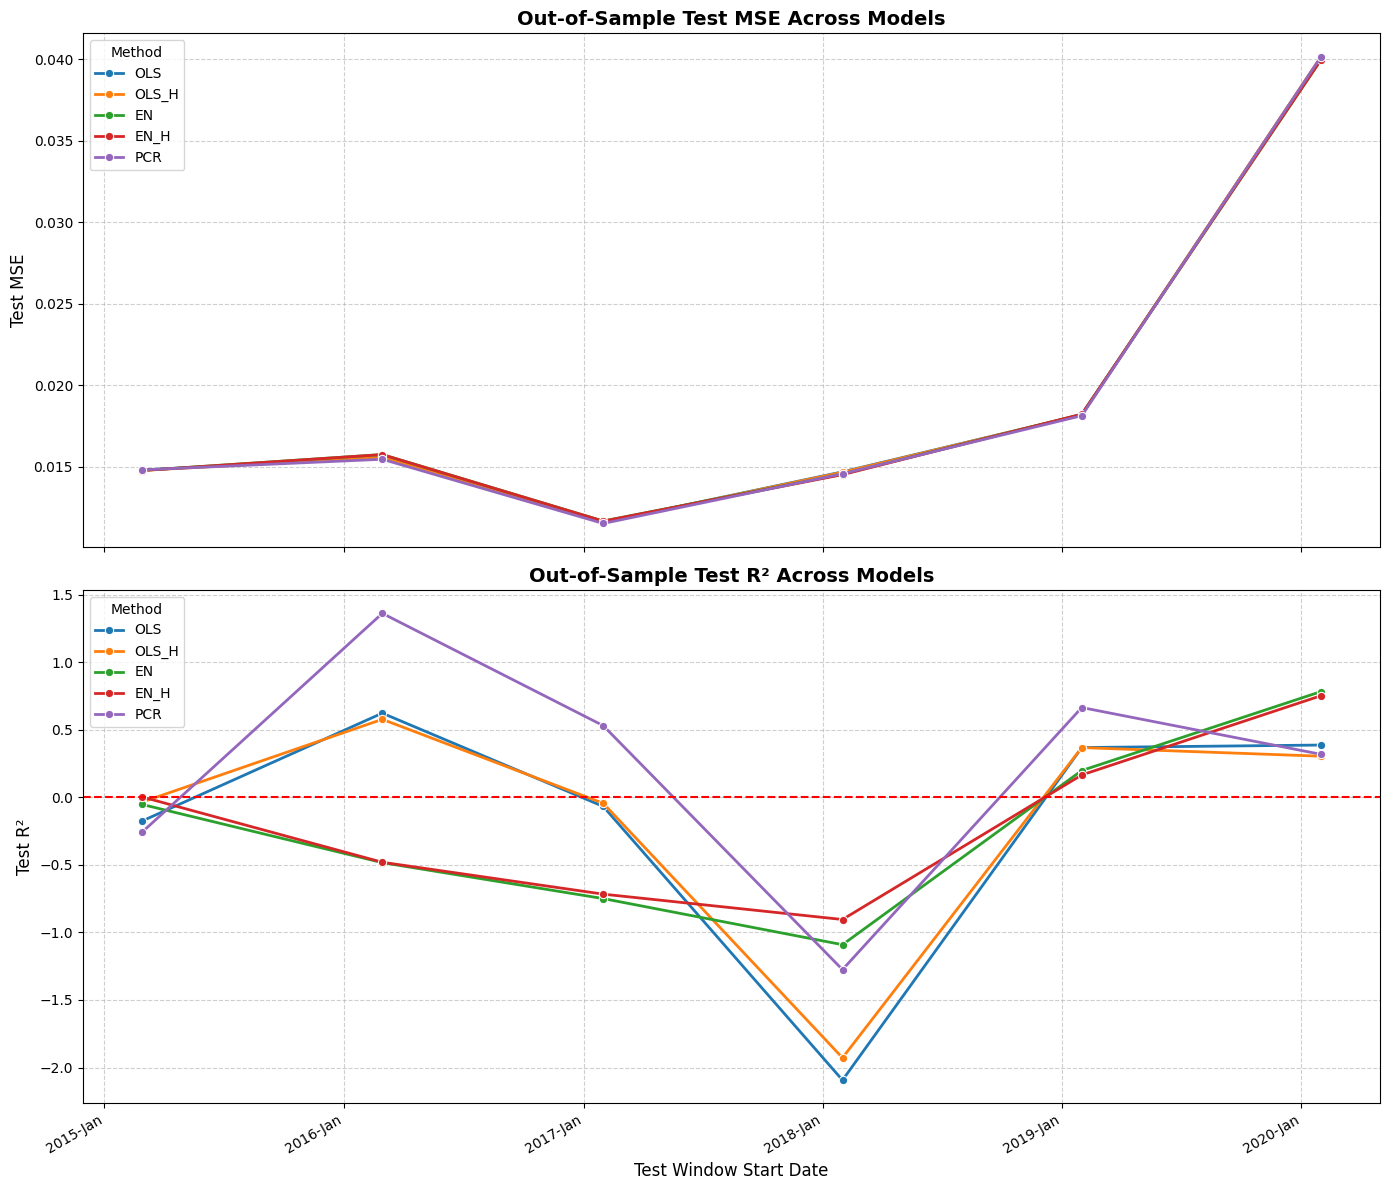

In [16]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 12),
    sharex=True
)

# ---------------------------------------------------
# Plot TEST MSE
# ---------------------------------------------------

sns.lineplot(
    data=all_models_mse,
    x='test_start',
    y='mse_test',
    hue='method',
    marker='o',
    linewidth=2,
    ax=axes[0]
)

axes[0].set_title(
    'Out-of-Sample Test MSE Across Models',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_ylabel('Test MSE', fontsize=12)

axes[0].grid(True, linestyle='--', alpha=0.6)

axes[0].legend(title='Method')

# ---------------------------------------------------
# Plot TEST R²
# ---------------------------------------------------

sns.lineplot(
    data=all_models_mse,
    x='test_start',
    y='r2_test',
    hue='method',
    marker='o',
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title(
    'Out-of-Sample Test R² Across Models',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Test Window Start Date', fontsize=12)

axes[1].set_ylabel('Test R²', fontsize=12)

axes[1].grid(True, linestyle='--', alpha=0.6)

# Reference line at R² = 0
axes[1].axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=1.5
)

axes[1].legend(title='Method')

# ---------------------------------------------------
# Format dates
# ---------------------------------------------------

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%b')
)

fig.autofmt_xdate()

plt.tight_layout()

In [17]:
all_models_mse.to_csv('/common/home/lh811/Documents/ML_Pricing/data/individual_model_performance/linear_models.csv', index=False)
#

In [18]:
all_models_mse[all_models_mse['method']=='EN_H']

,val_start,val_end,test_start,test_end,r2_val,mse_val,mse_test,r2_test,method,best_alpha,best_l1_ratio,huber_val,optimal_components
18,NaN,NaN,2015-02-27,2016-01-29,-0.326533,NaN,0.014768,0.004078,EN_H,0.1,0.5,0.008720,NaN
19,NaN,NaN,2016-02-29,2016-12-30,-0.298384,NaN,0.015747,-0.480382,EN_H,0.1,0.5,0.008288,NaN
20,NaN,NaN,2017-01-31,2017-12-29,-0.482964,NaN,0.011663,-0.716440,EN_H,0.1,0.5,0.008419,NaN
21,NaN,NaN,2018-01-31,2018-12-31,-0.180050,NaN,0.014515,-0.904190,EN_H,0.1,0.5,0.008439,NaN
22,NaN,NaN,2019-01-31,2019-12-31,-0.315482,NaN,0.018226,0.166096,EN_H,0.1,0.5,0.008640,NaN
23,NaN,NaN,2020-01-31,2021-01-29,-0.673729,NaN,0.039988,0.752755,EN_H,0.1,0.5,0.009022,NaN
